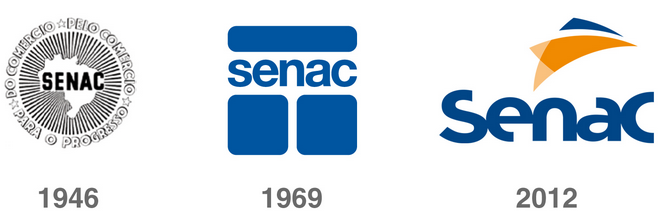

2025.08.145 - Técnico em Inteligência Artificial

Unidade Curricular: Utilizar estatística aplicada em aplicações de Inteligência Artificial - 60h

- 50 horas é presencial
- 10 horas que é assíncrono

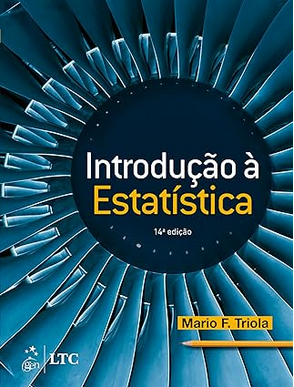

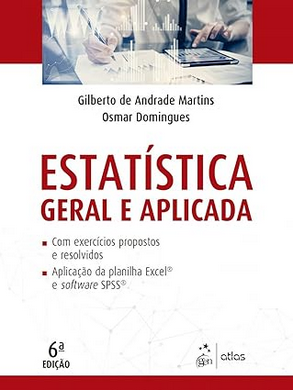

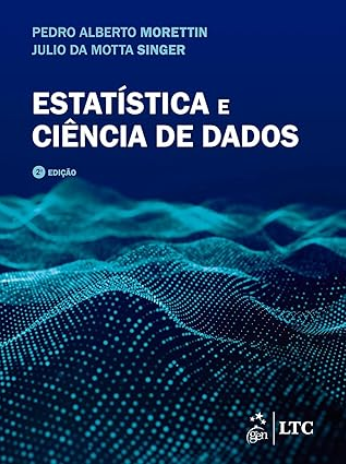

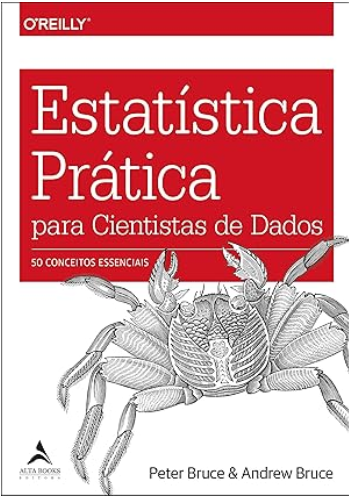

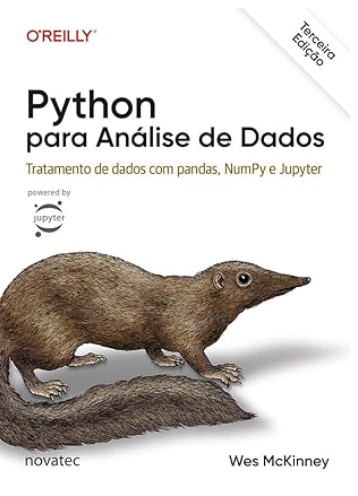

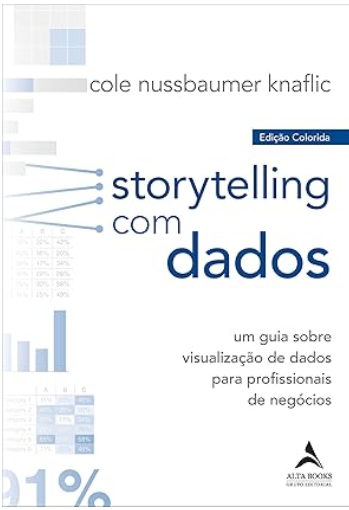

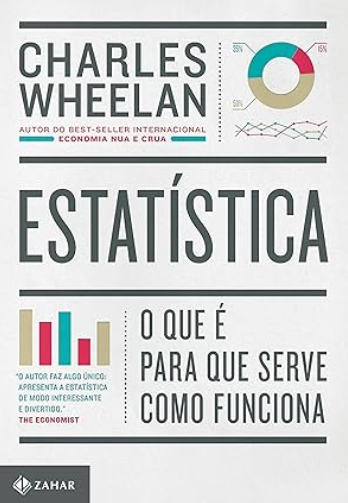

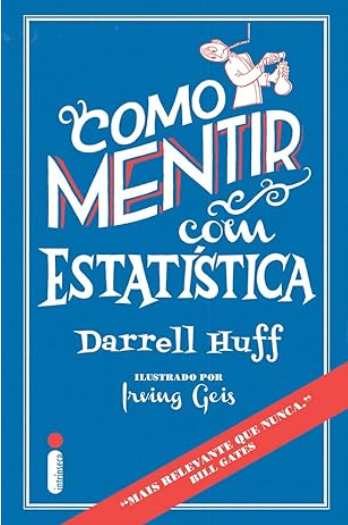

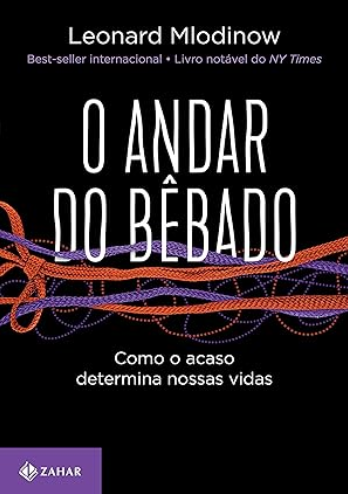

Biblioteca Física: A Estatística Básica e Sua Prática
(David S. Moore, William L. Notz, Michael A. Fligner)

Biblioteca Virtual: pesquisar na biblioteca virtual.

### Linguagens de Programação (para estatística)

In [10]:
# Python
# R
# Julia
# As funções do Excel (Estatística)

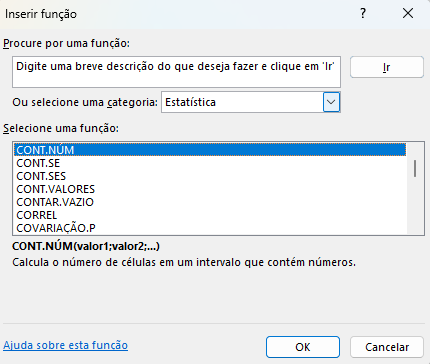

### Estatística Descritiva

#### Introdução

- Insights
- Básica (população, amostra, amostragem, parâmetro, estimador e estimativa)



##### Experimento cientifico

- População: é todo o conjunto do experimento.
- Resultado: parâmetros

In [11]:
total_bets_brasil = 187.00
print(f"Total de Bets no Brasil:{total_bets_brasil:.2f}")

Total de Bets no Brasil:187.00


In [12]:
# Crie uma amostra de 10 valores do faturamento de 10 Bets.
lista_bets = [15.5, 22.3, 18.7, 25.0, 30.2, 12.8, 20.1, 17.6, 19.4, 23.5]

Amostra --> Resultado = Estatística

#### Tipos de Dados 
- Engenharia de Variáveis
- Classifica as variáveis

In [13]:
import pandas as pd

In [14]:
dados_bets = pd.read_csv("data/maiores_marcas_bets_brasil.csv", sep=",")

In [15]:
dados_bets.head(10)

,Posição,Marca,Faturamento
0,1,Betano,"1,429 bilhão"
1,2,Bet365,741 bilhões
2,3,Sportingbet,540 bilhões
3,4,Esportes da Sorte,425 milhões
4,5,Superbet,361 milhões
5,6,Betnacional,359 milhões
6,7,7Games,285 milhões
7,8,EstrelaBet,175 milhões
8,9,VaideBet,164 milhões
9,10,Onabet,143 milhões


In [16]:
# armazenar apenas os 10 primeiros registros do DataFrame em uma nova variável
top_10_bets = dados_bets.head(10)

In [17]:
top_10_bets

,Posição,Marca,Faturamento
0,1,Betano,"1,429 bilhão"
1,2,Bet365,741 bilhões
2,3,Sportingbet,540 bilhões
3,4,Esportes da Sorte,425 milhões
4,5,Superbet,361 milhões
5,6,Betnacional,359 milhões
6,7,7Games,285 milhões
7,8,EstrelaBet,175 milhões
8,9,VaideBet,164 milhões
9,10,Onabet,143 milhões


In [18]:
print("posição: variável qualitativa ordinal")

posição: variável qualitativa ordinal


#### Quantitativa e Qualitativa

- Quantitativa: contagens númericas
- Qualitativos: categorias


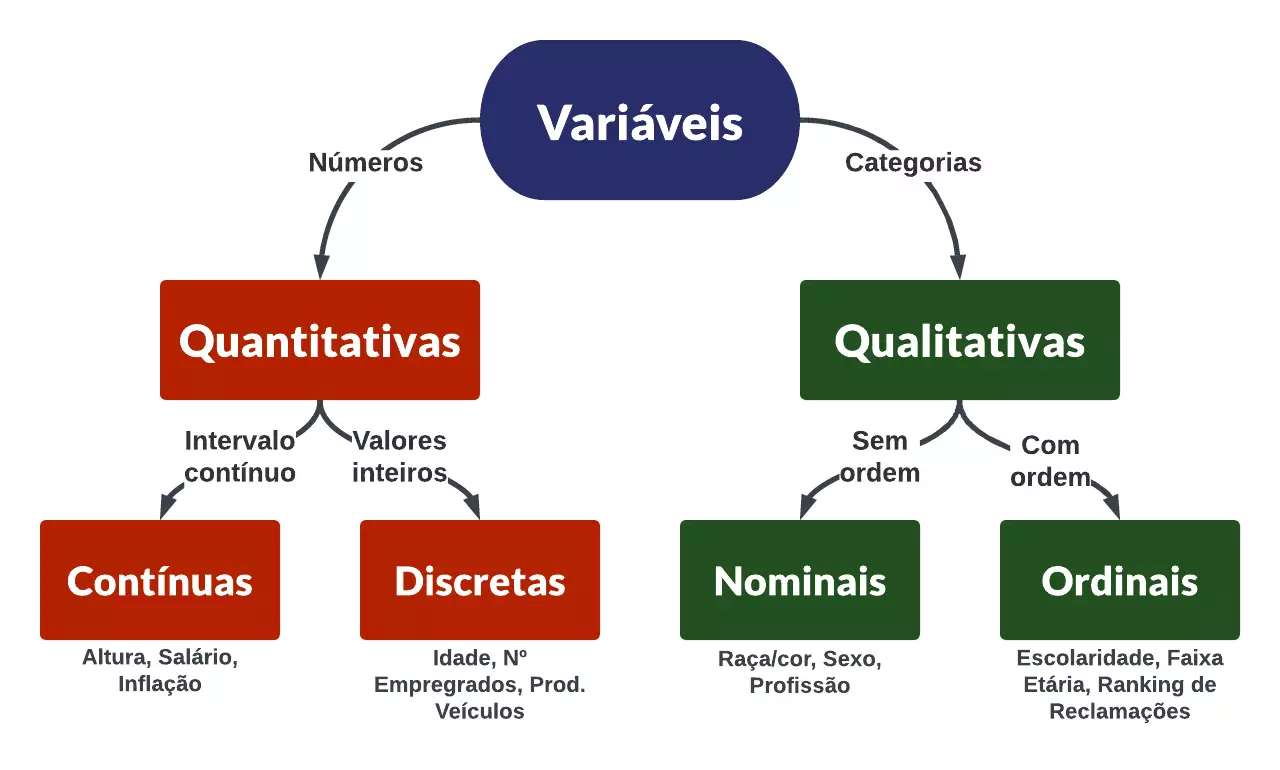

- Quantitativas (Discreta,Continua)
        Discreto (contagens)
        Contínuos (mensurações)
- Qualitativos (Nominal (sem ordem,nomes etc..) - exemplo Marca)
               - Ordinal

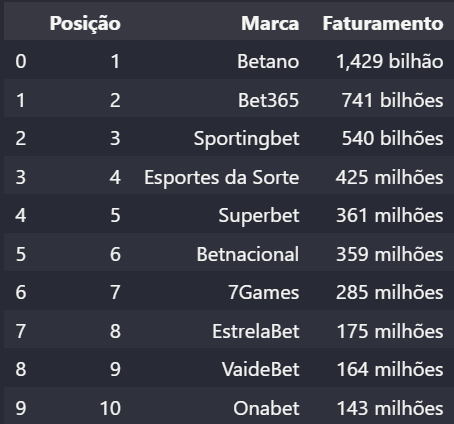

- Exercício: transformar a coluna faturamento em números

In [45]:
import pandas as pd
import numpy as np
import re # Usaremos 're' para substituições mais robustas

# 1. Criação do DataFrame de Exemplo (Assumindo que seus dados foram lidos assim)
data = {
    'Posição': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Marca': ['Betano', 'Bet365', 'Sportingbet', 'Esportes da Sorte', 'Superbet', 'Betnacional', '7Games', 'EstrelaBet', 'VaideBet', 'Onabet'],
    'Faturamento': ['1,429 bilhão', '741 bilhões', '540 bilhões', '425 milhões', '361 milhões', '359 milhões', '285 milhões', '175 milhões', '164 milhões', '143 milhões']
}
df = pd.DataFrame(data)

# 2. Função para converter o texto em número
def converter_faturamento(faturamento_str):
    """Converte strings como '1,429 bilhão' em valores numéricos."""
    faturamento_str = str(faturamento_str).replace('.', '').replace(',', '.') # Padroniza para formato decimal americano (ponto como separador)

    # Verifica se contém 'bilhão' ou 'bilhões'
    if re.search(r'bilh[ãa]o|bilh[õo]es', faturamento_str, re.IGNORECASE):
        # Remove a palavra e multiplica por 1 bilhão (1e9)
        valor = re.sub(r'\s*bilh[ãa]o|bilh[õo]es', '', faturamento_str, flags=re.IGNORECASE).strip()
        return float(valor) * 1e9

    # Verifica se contém 'milhão' ou 'milhões'
    elif re.search(r'milh[ãa]o|milh[õo]es', faturamento_str, re.IGNORECASE):
        # Remove a palavra e multiplica por 1 milhão (1e6)
        valor = re.sub(r'\s*milh[ãa]o|milh[õo]es', '', faturamento_str, flags=re.IGNORECASE).strip()
        return float(valor) * 1e6
        
    else:
        # Se não tiver o sufixo, tenta converter diretamente (caso haja outros formatos)
        try:
            return float(faturamento_str)
        except ValueError:
            return np.nan # Retorna NaN para valores que não podem ser convertidos

# 3. Aplicar a função à coluna 'Faturamento'
df['Faturamento_Numerico'] = df['Faturamento'].apply(converter_faturamento)

# 4. Exibir o resultado
print("DataFrame Original:")
print(df[['Marca', 'Faturamento']])

print("\nDataFrame com Faturamento Numérico (em Reais - R$):")
# Formata para notação científica para melhor visualização (ou R$)
pd.options.display.float_format = '{:,.2f}'.format
print(df[['Marca', 'Faturamento_Numerico']]) 

print("\nVerificação do Tipo de Dados:")
print(df['Faturamento_Numerico'].dtype)

DataFrame Original:
               Marca   Faturamento
0             Betano  1,429 bilhão
1             Bet365   741 bilhões
2        Sportingbet   540 bilhões
3  Esportes da Sorte   425 milhões
4           Superbet   361 milhões
5        Betnacional   359 milhões
6             7Games   285 milhões
7         EstrelaBet   175 milhões
8           VaideBet   164 milhões
9             Onabet   143 milhões

DataFrame com Faturamento Numérico (em Reais - R$):
               Marca  Faturamento_Numerico
0             Betano      1,429,000,000.00
1             Bet365    741,000,000,000.00
2        Sportingbet    540,000,000,000.00
3  Esportes da Sorte        425,000,000.00
4           Superbet        361,000,000.00
5        Betnacional        359,000,000.00
6             7Games        285,000,000.00
7         EstrelaBet        175,000,000.00
8           VaideBet        164,000,000.00
9             Onabet        143,000,000.00

Verificação do Tipo de Dados:
float64


In [46]:
df.head(10)

,Posição,Marca,Faturamento,Faturamento_Numerico
0,1,Betano,"1,429 bilhão","1,429,000,000.00"
1,2,Bet365,741 bilhões,"741,000,000,000.00"
2,3,Sportingbet,540 bilhões,"540,000,000,000.00"
3,4,Esportes da Sorte,425 milhões,"425,000,000.00"
4,5,Superbet,361 milhões,"361,000,000.00"
5,6,Betnacional,359 milhões,"359,000,000.00"
6,7,7Games,285 milhões,"285,000,000.00"
7,8,EstrelaBet,175 milhões,"175,000,000.00"
8,9,VaideBet,164 milhões,"164,000,000.00"
9,10,Onabet,143 milhões,"143,000,000.00"


In [47]:
# ordenar a coluna 'Faturamento_Numerico' em ordem decrescente
df_ordenado = df.sort_values(by='Faturamento_Numerico', ascending=False)

In [48]:
df_ordenado.head(10)

,Posição,Marca,Faturamento,Faturamento_Numerico
1,2,Bet365,741 bilhões,"741,000,000,000.00"
2,3,Sportingbet,540 bilhões,"540,000,000,000.00"
0,1,Betano,"1,429 bilhão","1,429,000,000.00"
3,4,Esportes da Sorte,425 milhões,"425,000,000.00"
4,5,Superbet,361 milhões,"361,000,000.00"
5,6,Betnacional,359 milhões,"359,000,000.00"
6,7,7Games,285 milhões,"285,000,000.00"
7,8,EstrelaBet,175 milhões,"175,000,000.00"
8,9,VaideBet,164 milhões,"164,000,000.00"
9,10,Onabet,143 milhões,"143,000,000.00"


#### Medidas de Tendência Central

- Media
- Mediana
- Moda


#### Medidas de posição relativas

- Decis
- Percentis
- Quartis

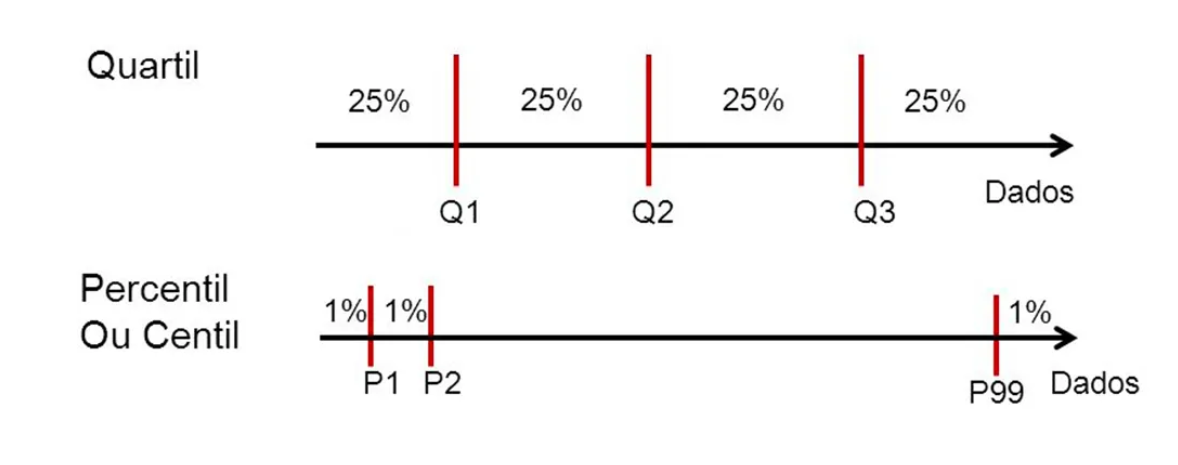

In [49]:
df_bet = pd.read_csv("data/lucro_bets.csv", sep=",")

In [50]:
df_bet

,Posição,Marca,Faturamento_Texto,Faturamento_Reais
0,1,Betano,"1,429 bilhões",1429000000
1,2,Bet365,741 bilhões,741000000
2,3,Sportingbet,540 bilhões,540000000
3,4,Esportes da Sorte,425 milhões,425000000
4,5,Superbet,361 milhões,361000000
5,6,Betnacional,359 milhões,359000000
6,7,7Games,285 milhões,285000000
7,8,EstrelaBet,175 milhões,175000000
8,9,VaideBet,164 milhões,164000000
9,10,Onabet,143 milhões,143000000


In [52]:
novo_data_bets = df_bet[['Marca', 'Faturamento_Reais']]

In [53]:
novo_data_bets

,Marca,Faturamento_Reais
0,Betano,1429000000
1,Bet365,741000000
2,Sportingbet,540000000
3,Esportes da Sorte,425000000
4,Superbet,361000000
5,Betnacional,359000000
6,7Games,285000000
7,EstrelaBet,175000000
8,VaideBet,164000000
9,Onabet,143000000


In [55]:
novo_data_bets.describe()

,Faturamento_Reais
count,20.00
mean,"270,400,000.00"
std,"331,198,684.21"
min,"54,000,000.00"
25%,"79,250,000.00"
50%,"129,000,000.00"
75%,"359,500,000.00"
max,"1,429,000,000.00"


### Exercício 01

- Média aritmética simples
- Mediana : par ou impar?
- Moda
- Amodal

### Qual a melhor medida de tendencia central?

considerando os dados

- a) 1 - 2 -3 -4 -5
- b) 1 - 2 -3 -4 - 50

- Media
- Mediana

#### Medidas de Dispersão

#### Gráficos  - parte 1 (comuns)

#### Gráficos - parte 2 (mais específicos)

#### Tabelas (parte 1) - distribuições e frequências

#### Tabelas (parte 2) - tabelas cruzadas

#### Probabilidade (modelos probabilísticos)

### Estatística Bayesiana

- Inferência
- Intuição

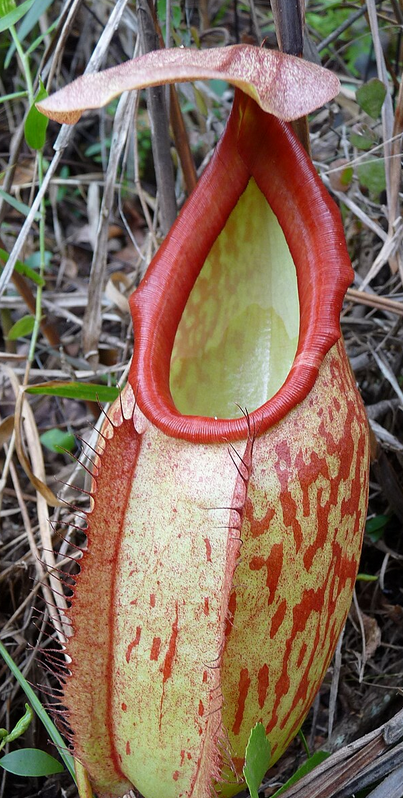

#### Links importantes da aula

- https://dontpad.com/datasetbet

- https://www.meioemensagem.com.br/marketing/as-20-maiores-marcas-de-bets-em-operacao-no-brasil

- https://drive.google.com/drive/folders/16jeBs5mOiExah8yvfX-P1LOcKkJJRbzt